In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("./data/merged_dataset.csv")
df.tail()

,Unnamed: 0,cbsa,Date,AQI,Category
6072426,5885923,"Yuma, AZ",2025-09-26,47,Good
6072427,5824578,"Yuma, AZ",2025-09-27,42,Good
6072428,5885924,"Yuma, AZ",2025-09-28,47,Good
6072429,6025673,"Yuma, AZ",2025-09-29,67,Moderate
6072430,5802632,"Yuma, AZ",2025-09-30,39,Good


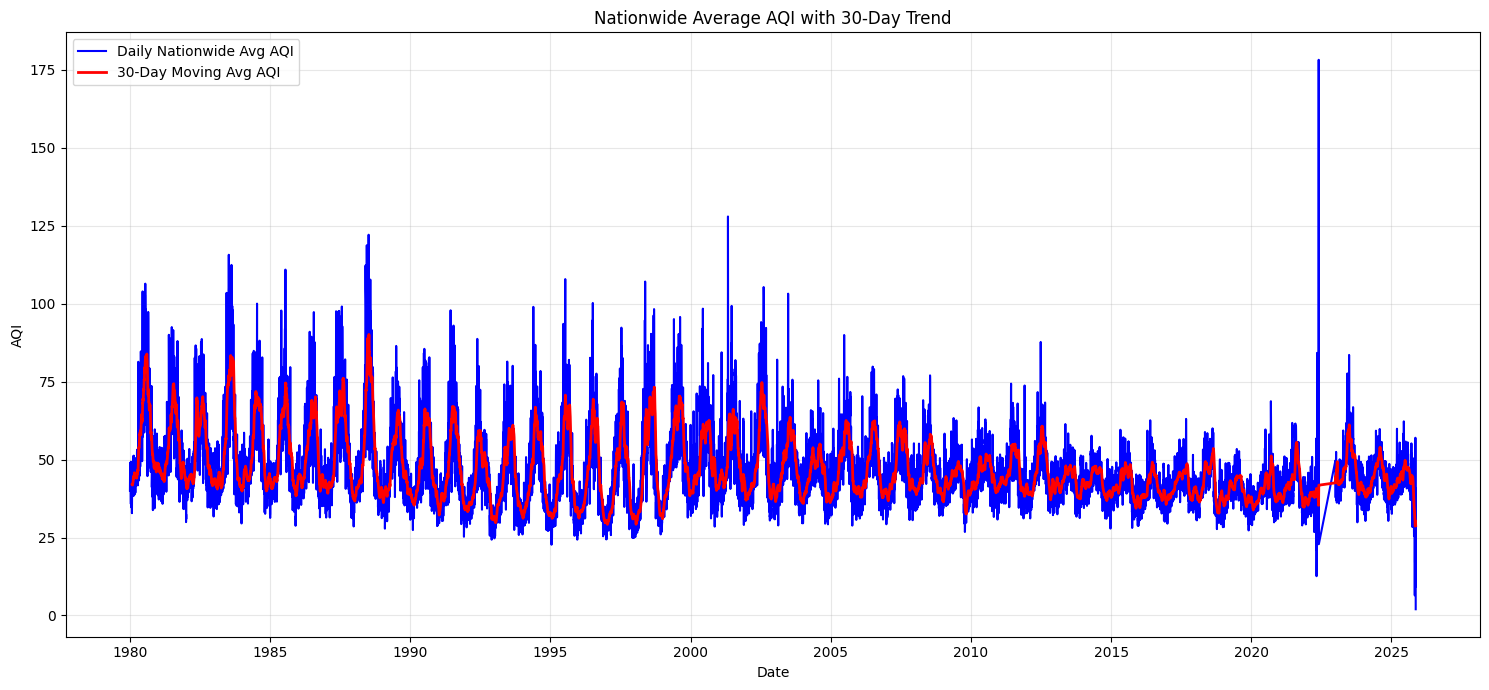

In [2]:
df['Date'] = pd.to_datetime(df['Date'])

# 1. Calculate Nationwide Average AQI per day
# We group by the 'Date' and take the mean of 'AQI' across all locations for that day
daily_nationwide_avg = df.groupby('Date')['AQI'].mean()

# 2. Calculate 30-day moving average
# This takes the average of the previous 30 days for each point to show the trend
rolling_30d_avg = daily_nationwide_avg.rolling(window=30).mean()

# 3. Plotting
plt.figure(figsize=(15, 7))

# Plot the daily average in the background (lighter color)
plt.plot(daily_nationwide_avg.index, daily_nationwide_avg, 
         label='Daily Nationwide Avg AQI', color='blue', linestyle='-')

# Plot the 30-day moving average on top (darker, thicker line)
plt.plot(rolling_30d_avg.index, rolling_30d_avg, 
         label='30-Day Moving Avg AQI', color='red', linewidth=2)

plt.title('Nationwide Average AQI with 30-Day Trend')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

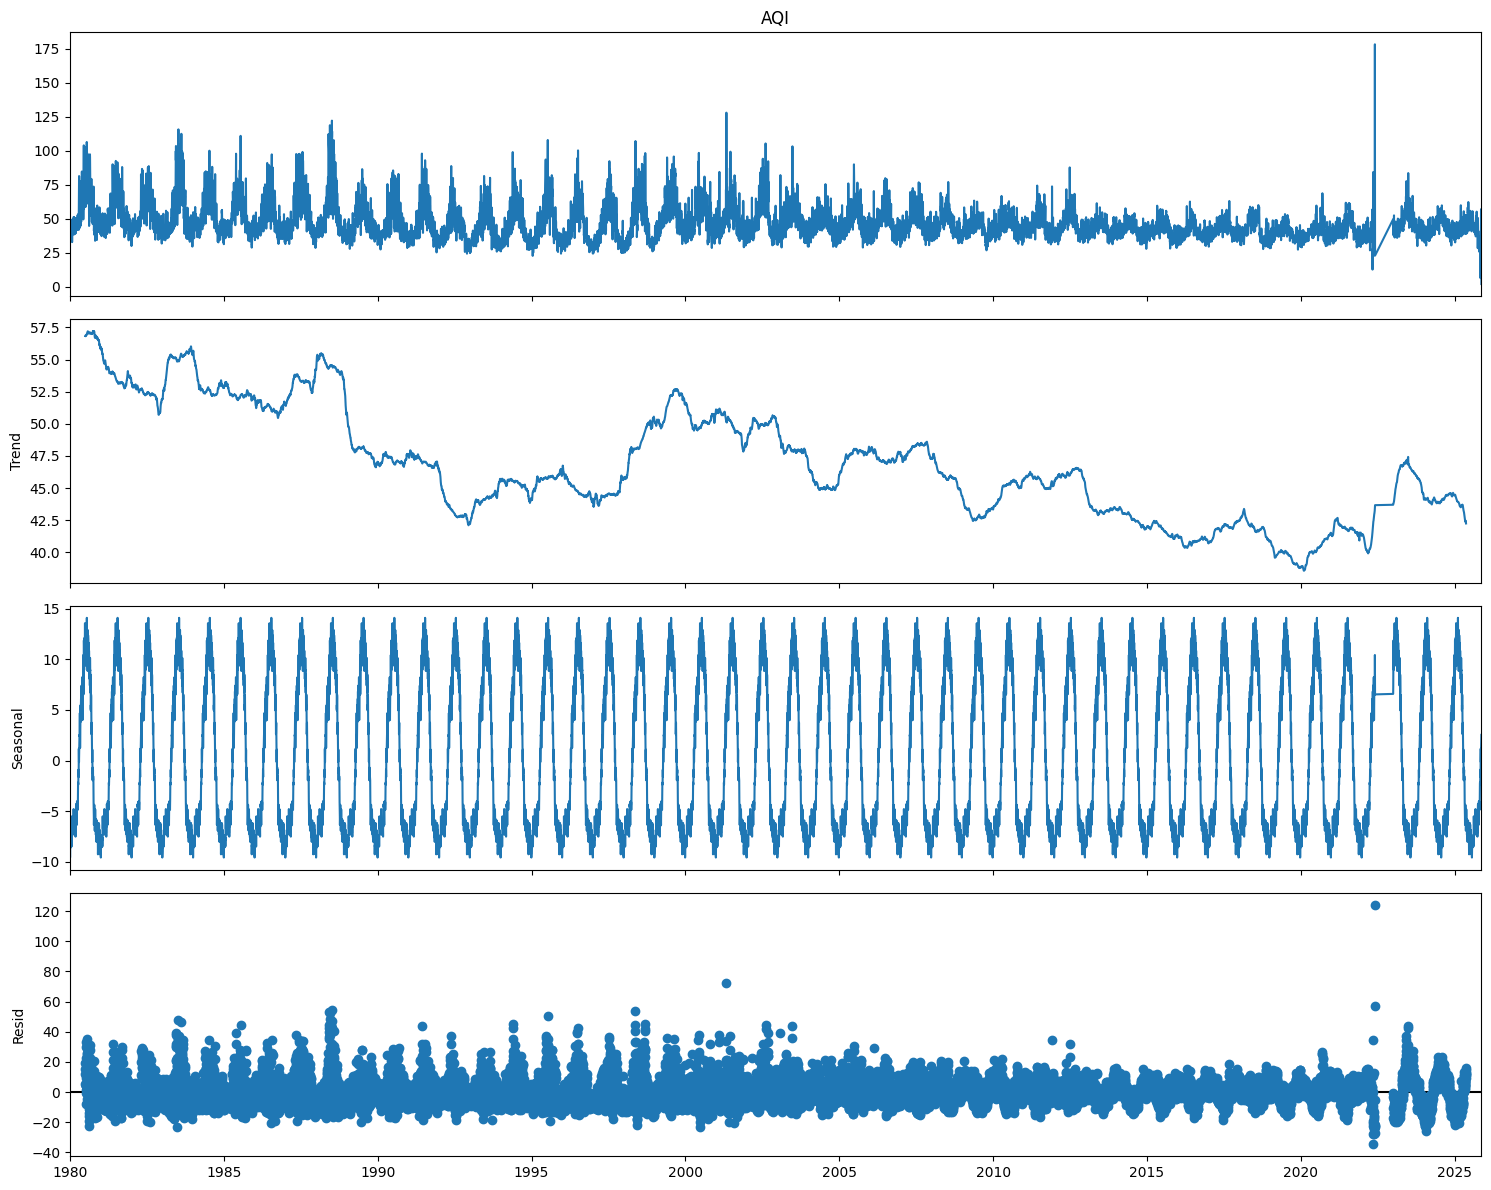

In [3]:
# Noticed a seasonal trend. Performing a Classical Decomposition Analysis

from statsmodels.tsa.seasonal import seasonal_decompose

# We use the daily_nationwide_avg series you created in the previous step.
# period=365 specifies that the seasonality repeats every year (365 days).
# model='additive' is used because the magnitude of the seasonality 
# doesn't appear to change drastically over time (the waves stay roughly the same size).

decomposition = seasonal_decompose(daily_nationwide_avg.dropna(), model='additive', period=365)

# Plot the four components: Observed, Trend, Seasonal, and Residual
fig = decomposition.plot()
fig.set_size_inches(15, 12) # Make it large enough to read
plt.tight_layout()
plt.show()

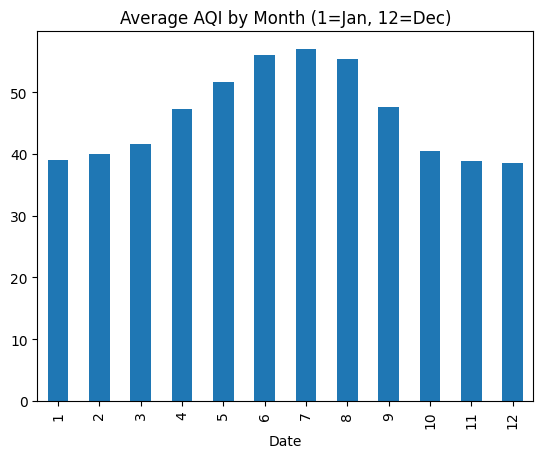

In [4]:
# Group by month to see the average seasonal pattern
monthly_avg = df.groupby(df['Date'].dt.month)['AQI'].mean()
monthly_avg.plot(kind='bar', title='Average AQI by Month (1=Jan, 12=Dec)')
plt.show()

In [5]:
# Finding days most different from expected

# access the residual component from your decomposition variable
residuals = decomposition.resid.dropna()

# Find days where the residual was very high (e.g., > 20)
extreme_days = residuals[residuals > 20]
print("Top 10 Most Anomalous Days:")
print(extreme_days.sort_values(ascending=False).head(10))

Top 10 Most Anomalous Days:
Date
2022-05-29    124.294789
2001-05-02     72.311179
2022-05-28     57.106788
1988-07-07     54.700338
1998-05-19     53.570131
1988-05-28     52.749424
1988-06-13     52.393706
1995-07-13     50.562795
1988-06-15     48.257142
1983-07-12     47.605534
Name: resid, dtype: float64


In [6]:
# Finding gap in chart

# 1. Get the dates from your series index
dates = daily_nationwide_avg.index.to_series()

# 2. Calculate the difference between each date and the previous one
date_diffs = dates.diff()

# 3. Filter for gaps larger than 1 day
# We look for differences > 1 day. 
# The "date" found is the FIRST day back after the gap.
gaps = date_diffs[date_diffs > pd.Timedelta(days=1)]

print(f"Found {len(gaps)} gap(s) in the data:\n")

for end_date, duration in gaps.items():
    # The gap starts the day after the previous valid data point
    start_gap = end_date - duration + pd.Timedelta(days=1)
    # The gap ends the day before the data resumes
    end_gap = end_date - pd.Timedelta(days=1)
    
    print(f"Gap detected:")
    print(f"  Start: {start_gap.date()}")
    print(f"  End:   {end_gap.date()}")
    print(f"  Days missing: {duration.days - 1}")
    print("-" * 30)

Found 1 gap(s) in the data:

Gap detected:
  Start: 2022-06-01
  End:   2022-12-31
  Days missing: 214
------------------------------


This gap is likely caused by the merging from government dataset and kaggle dataset. Since kaggle advertised that it went from 1980-2022 we assumed it went through the entirety of 2022, not that it stopped in the middle.

In [7]:
# Accessing Trend diagram from CDA

# 1. Access the trend component directly
trend_data = decomposition.trend

# 2. Drop the 'NaN' values to see only the valid calculated points
# (The trend calculation cuts off a few months at the start and end)
valid_trend = trend_data.dropna()

# 3. Get the very last valid point
last_value = valid_trend.iloc[-1]
last_date = valid_trend.index[-1]

# 4. Get First valid Point
first_value = valid_trend.iloc[0]
first_date = valid_trend.index[0]

print(f"The first calculated trend value is: {first_value:.2f}")
print(f"This trend value corresponds to date: {first_date.date()}")

print(f"The last calculated trend value is: {last_value:.2f}")
print(f"This trend value corresponds to date: {last_date.date()}")

The first calculated trend value is: 56.84
This trend value corresponds to date: 1980-07-01
The last calculated trend value is: 42.25
This trend value corresponds to date: 2025-05-15


In [8]:
# Starting analysis for the big spike in AQI on 2022-05-29

# Filter for the specific anomalous date
day_data = df[df['Date'] == '2022-05-29']

# 1. See how many stations reported that day (is it far fewer than normal?)
print(f"Number of reporting locations: {len(day_data)}")

# 2. See the top 10 highest AQI values for that day
print("\nHighest AQI recordings on 2022-05-29:")
print(day_data.sort_values('AQI', ascending=False).head(10)[['cbsa', 'AQI', 'Category']])

# 3. Check for suspiciously high 'perfect' numbers (like 500, 999)
print("\nDescriptive Statistics for the day:")
print(day_data['AQI'].describe())

Number of reporting locations: 9

Highest AQI recordings on 2022-05-29:
                     cbsa  AQI   Category
1627167     El Centro, CA  733  Hazardous
4498338     Riverside, CA  631  Hazardous
2085392  Grand Island, NE   54   Moderate
428623       Beatrice, NE   45       Good
4237217      Portland, ME   39       Good
388695         Bangor, ME   36       Good
1466376    Des Moines, IA   33       Good
3905976         Omaha, NE   24       Good
4926362   Scottsbluff, NE    9       Good

Descriptive Statistics for the day:
count      9.000000
mean     178.222222
std      287.029083
min        9.000000
25%       33.000000
50%       39.000000
75%       54.000000
max      733.000000
Name: AQI, dtype: float64


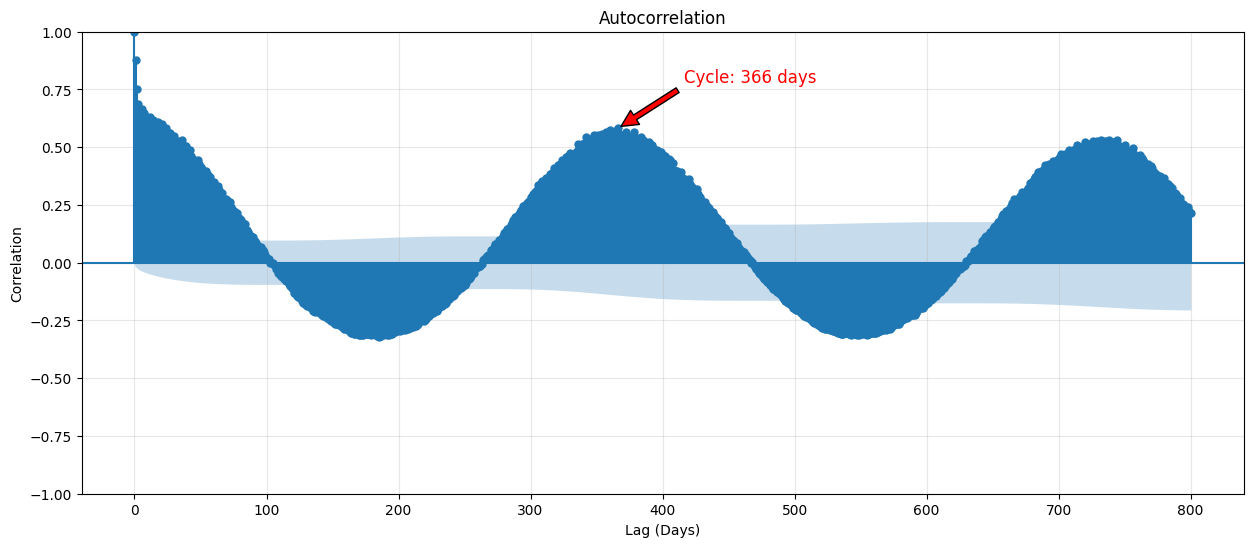

/tmp/ipykernel_3820295/2263668840.py:52: RuntimeWarning: divide by zero encountered in divide
  plt.plot(1/frequencies, magnitude, color='purple') # X-axis is Period (1/Freq)


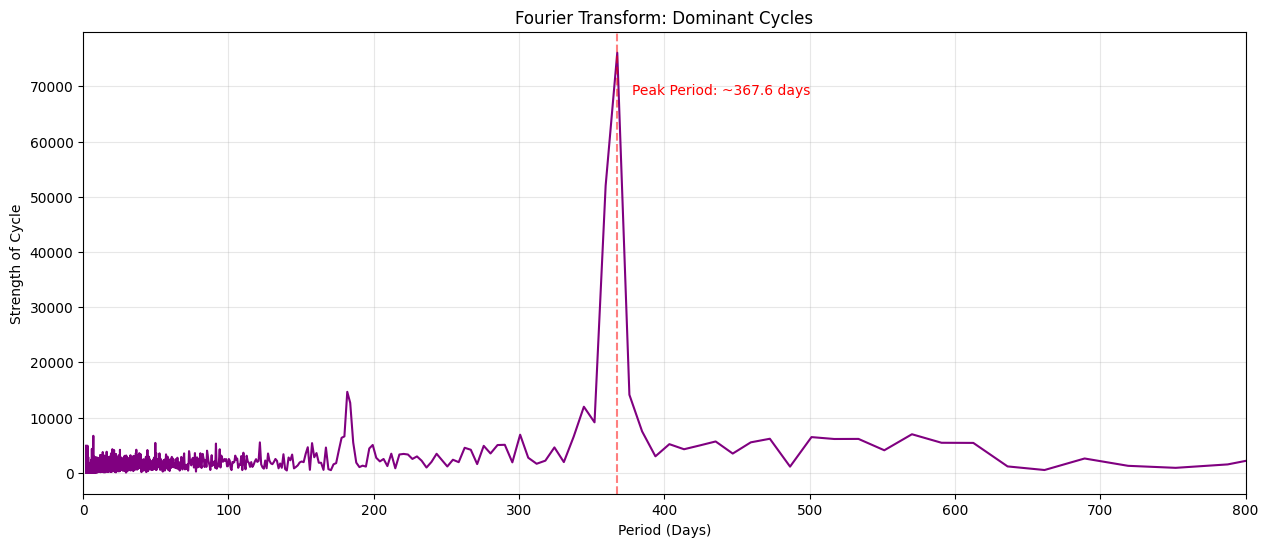

In [9]:
# Analysis on periodicity of the seasonality to determine when every peak is in seasonality

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

# Remove any missing data first
clean_data = daily_nationwide_avg.dropna()

# --- METHOD 1: Autocorrelation Plot (ACF) with Annotation ---

# 1. Calculate the actual ACF values to find the exact peak
# nlags=800 ensures we calculate enough data points to cover our range
acf_values = acf(clean_data, nlags=800)

# 2. Find the index of the max value specifically between lag 300 and 400
search_range = acf_values[300:400]
peak_index_in_range = np.argmax(search_range)
peak_lag = 300 + peak_index_in_range # Adjust index back to global lag
peak_correlation = acf_values[peak_lag]

# 3. Plot
plt.figure(figsize=(15, 6))
# ax=plt.gca() ensures we plot on the figure we just created
plot_acf(clean_data, lags=800, alpha=0.05, title='Autocorrelation', use_vlines=True, ax=plt.gca())

# 4. Add Annotation to the specific peak
plt.annotate(f'Cycle: {peak_lag} days', 
             xy=(peak_lag, peak_correlation), 
             xytext=(peak_lag + 50, peak_correlation + 0.2), # Position text slightly away
             arrowprops=dict(facecolor='red', shrink=0.05),
             fontsize=12, color='red')

plt.xlabel('Lag (Days)')
plt.ylabel('Correlation')
plt.grid(True, alpha=0.3)
plt.show()

# --- METHOD 2: Fast Fourier Transform (FFT) ---
# This breaks the signal into frequencies to find the "loudest" cycle.
fft_values = np.fft.rfft(clean_data)
frequencies = np.fft.rfftfreq(len(clean_data), d=1) # d=1 implies daily data

# Calculate magnitude (power) of each frequency
magnitude = np.abs(fft_values)

# Filter out the "0" frequency (the average/DC component) to see the cycles clearly
magnitude[0] = 0

plt.figure(figsize=(15, 6))
plt.plot(1/frequencies, magnitude, color='purple') # X-axis is Period (1/Freq)
plt.title('Fourier Transform: Dominant Cycles')
plt.xlabel('Period (Days)')
plt.ylabel('Strength of Cycle')
plt.xlim(0, 800) # Zoom in to see up to 2-year cycles
plt.grid(True, alpha=0.3)

# Annotate the strongest peak
peak_freq_idx = np.argmax(magnitude)
peak_period = 1/frequencies[peak_freq_idx]
plt.axvline(peak_period, color='red', linestyle='--', alpha=0.5)
plt.text(peak_period + 10, max(magnitude)*0.9, f'Peak Period: ~{peak_period:.1f} days', color='red')

plt.show()

The seasonality being more than 365 days is likely due to missing data